In [53]:
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib.animation as animation
import cartopy
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
import numpy as np
from IPython.display import HTML
from glob import glob

In [2]:
dataset = xr.merge([xr.open_dataset(f) for f in glob('icon-mpi-dwd.52.medium.L30.latlon.nonhydro_DOM01_PL*.nc')])

In [39]:
u = dataset['u']
u.dims, u.shape, u.coords


(('time', 'plev', 'lat', 'lon'),
 (41, 3, 181, 360),
 Coordinates:
   * time     (time) float64 328B 2.008e+07 2.008e+07 ... 2.008e+07 2.008e+07
   * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
   * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
   * plev     (plev) float64 24B 2e+04 5e+04 8.5e+04)

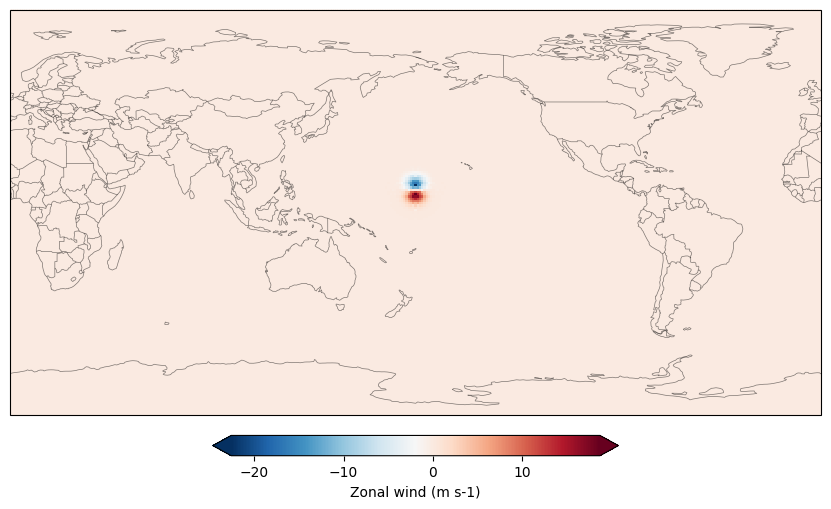

In [68]:
lon, lat = dataset['lon'], dataset['lat']
data = u[:,-1]
cb_label = '{} ({})'.format(u.attrs['long_name'], u.attrs['units'])

map_proj = ccrs.PlateCarree(central_longitude=180)

fig, ax = plt.subplots(
    figsize=(10, 5), layout="compressed", facecolor="w", dpi=100,
    subplot_kw=dict(projection=map_proj),
)

ax.coastlines(resolution='110m', color='k', lw=.5, alpha=.5)
ax.add_feature(cartopy.feature.BORDERS, ec='k', lw=.5, alpha=.5)
im = ax.pcolormesh(lon, lat, data[0], transform=ccrs.PlateCarree(), cmap="RdBu_r")

cb = fig.colorbar(im, shrink=.5, orientation='horizontal', extend="both", label=cb_label)

def update(frame):
    im.set_array(data[frame])

anim = animation.FuncAnimation(fig=fig, func=update, frames=u.shape[0], interval=100)
HTML(anim.to_html5_video())

anim.save('cyclone_r2b4.gif')
